In [1]:
from IPython.display import Image

> Almost all Chinese AI companies are trying to solve the ''**curse of depth**'': Qwen3.5 (layer rearrangement), deepseep's mHC, Kimi's Attention Residuals, bytedance (HC, KEEL).

- @ilyasut once said that an LSTM is a ResNet rotated 90 degrees. :) It turns out attention can be rotated 90 degrees too — yielding a natural generalization of residual connections.
    - Yulun Du
- SGD is a ResNet too (the blocks of it are fwd+bwd), the residual stream is the weights so... 🤔 We're not taking the Attention is All You Need part literally enough? :D
    - Andrew Karpathy
- references
    - https://www.k-a.in/AttnRes.html
        - https://colab.research.google.com/drive/1FGVHFRY2ShFeQWPXTW30e_K-caW1_l-S?usp=sharing

### 概览

> attention residual: 注意力风格的 residual

- 为什么标准残差会在深层网络里产生“PreNorm dilution”
- perspective：把残差连接看成沿着深度轴的状态递推
    - 将大模型的深度（Depth）类比为一条时间线，将每一层（Layer）类比为时间线上的独立工作站（加工处理，不同的工序）。
    - 第 $l$ 层在进行计算时，应当如何从前面 $0$ 到 $l-1$ 层的历史输出中，提取并混合对自己最有价值的信息
    - attention + ffn
        - Attention: token interaction, 类似于“情报局”（负责全局序列信息的混合与宏观依赖），
        - MLP: token projection, 层类似于“执行局”（负责局部通道特征的非线性转换） 。
- Attention Residuals: A Unified View of Time and Depth

In [4]:
import math
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
np.random.seed(7)
torch.manual_seed(7)

In [6]:
def softmax(x, axis=-1):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=axis, keepdims=True)


def rmsnorm(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    rms = np.sqrt(np.mean(np.square(x), axis=-1, keepdims=True) + eps)
    return x / rms


def cosine_similarity(a, b, eps=1e-8):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    num = np.sum(a * b, axis=-1)
    den = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1) + eps
    return num / den

### pre-norm vs. post-norm & res conn

> Residual connections with PreNorm are standard in modern LLMs, yet they accumulate all layer outputs with fixed unit weights.

In [2]:
Image(url='https://benjaminwarner.dev/img/2023/transformers-from-scratch/pre-post-norm.png', width=500)

- pre / post 指的是 norm 在 addition 之前还是之后
    - pre-norm 事前标准化，post-norm 事后标准化

- 在深度轴上，把所有过往层输出做了一个固定系数的累加。
    - 固定权重为1的无差别累加
------

- 标准残差写成：

$$
h_l = h_{l-1} + f_{l-1}(h_{l-1})
$$

- 展开后得到：

$$
h_l = h_1 + \sum_{i=1}^{l-1} 1\cdot f_i(h_i)
$$

#### Gradient analysis

> Gradient Highway

$$
\frac{\partial \mathcal{L}}{\partial h_l} = \frac{\partial \mathcal{L}}{\partial h_L} \cdot \prod_{j=l}^{L-1} \left( I + \frac{\partial f_j}{\partial h_j} \right)
$$

- $\frac{\partial h_{j+1}}{\partial h_j} = \frac{\partial}{\partial h_j} \left( h_j + f_j(h_j) \right)= I + \frac{\partial f_j}{\partial h_j}$
- $\frac{\partial \mathcal{L}}{\partial h_l} = \frac{\partial \mathcal{L}}{\partial h_L} \cdot \frac{\partial h_L}{\partial h_{L-1}} \cdot \frac{\partial h_{L-1}}{\partial h_{L-2}} \cdots \frac{\partial h_{l+1}}{\partial h_l}=\frac{\partial \mathcal{L}}{\partial h_L} \cdot \prod_{j=l}^{L-1} \frac{\partial h_{j+1}}{\partial h_j}= \frac{\partial \mathcal{L}}{\partial h_L} \cdot \prod_{j=l}^{L-1} \left( I + \frac{\partial f_j}{\partial h_j} \right)$

这意味着：对第 `l` 层而言，所有过去的 source(每一个layer的输入 embedding $h_\ell$) 都以 **相同系数 1** 被加进来。如果把“谁更重要”这个问题当成一个 mixing problem，那么标准残差相当于说：

> 不管 token 内容是什么 (Input-independent)，不管当前层在做 attention 还是 MLP (Structure-independent)，不管深度多深 (Depth-independent)，都用同一套固定权重。

- mixing problem
    - $h_l = w_0 h_1 + w_1 f_1(h_1) + w_2 f_2(h_2) + \dots + w_{l-1} f_{l-1}(h_{l-1})$
    - 在标准残差（Standard Residuals）的法则下，这个权重向量 $\mathbf{w}$ 被写死成了：
        - $[w_0, w_1, w_2, \dots, w_{l-1}] = [1, 1, 1, \dots, 1]$

这就引出了论文说的两个问题：

- **selectivity 不够**：不能选择性回看早期层；
- **PreNorm dilution**：随着深度增加，单层输出在总和里的相对份额变小。

In [33]:
torch.set_default_dtype(torch.float64)

d = 3
L = 6
Ws = [0.12 * torch.randn(d, d) for _ in range(L - 1)]
target = torch.randn(d)

h0 = torch.randn(d, requires_grad=True)
states = [h0]
h = h0
for W in Ws:
    h = h + W @ h
    h.retain_grad()
    states.append(h)

# scalar
loss = target @ states[-1]
loss.backward()

- 设初始状态向量为 $h_0 \in \mathbb{R}^d$，其中维度 $d = 3$。代码中 states 列表依次存储了 $h_0, h_1, \dots, h_{L-1}$。
- 权重矩阵：设权重矩阵序列为 $W_1, W_2, \dots, W_{L-1}$，对应代码中的 Ws 列表（共 $L-1 = 5$ 个，大小均为 $d \times d$）。
- 前向递推公式：代码中的 h = h + W @ h 构成了离散时间的动态转移方程。对于第 $t$ 步（$t = 1, 2, \dots, L-1$）：
    - $h_t = h_{t-1} + W_t h_{t-1} = (I + W_t) h_{t-1}$
- 标量损失函数：设目标向量 target 为 $y \in \mathbb{R}^d$。代码的最后一步 loss = target @ states[-1] 计算的是内积（标量），即
    - $\mathcal{L} = y^\top h_{L-1}$
------
Gradient analysis
- 为了求 $\mathcal{L}$ 对中间状态 $h_{t-1}$ 的梯度，需要求前向方程 $h_t = (I + W_t) h_{t-1}$ 的局部雅可比矩阵：
    - $\frac{\partial h_t}{\partial h_{t-1}} = I + W_t$
- 根据多元微积分的链式法则，当前步的梯度等于下一步的梯度左乘局部雅可比矩阵的转置：
    - $\frac{\partial \mathcal{L}}{\partial h_{t-1}} = \left( \frac{\partial h_t}{\partial h_{t-1}} \right)^\top \frac{\partial \mathcal{L}}{\partial h_t} = (I + W_t^\top) \frac{\partial \mathcal{L}}{\partial h_t}$
- 展开至初始状态的解析解
    - 由于代码中为每一个 h 调用了 retain_grad()，系统实际上保留了所有 $\frac{\partial \mathcal{L}}{\partial h_t}$ 的值。若将递推关系一直展开到 $h_0$，即可得到初始状态的完整梯度解析式：
        - $\frac{\partial \mathcal{L}}{\partial h_0} = (I + W_1^\top) (I + W_2^\top) \dots (I + W_{L-1}^\top) y$

In [34]:
direct_norms = []
formula_norms = []
max_abs_err = 0.0

for l in range(L):
    expected = target.clone()
    for j in range(L - 2, l - 1, -1):
        expected = (torch.eye(d) + Ws[j].T) @ expected
    direct = states[l].grad
    direct_norms.append(torch.linalg.norm(direct).item())
    formula_norms.append(torch.linalg.norm(expected).item())
    max_abs_err = max(max_abs_err, torch.max(torch.abs(direct - expected)).item())

grad_df = pd.DataFrame(
    {
        "layer_index": np.arange(L),
        "autograd_norm": direct_norms,
        "formula_norm": formula_norms,
    }
)
display(grad_df)
print(f"max |autograd - formula| = {max_abs_err:.3e}")

,layer_index,autograd_norm,formula_norm
0,0,1.793398,1.793398
1,1,1.674881,1.674881
2,2,1.828759,1.828759
3,3,2.121682,2.121682
4,4,2.100036,2.100036
5,5,1.811266,1.811266


max |autograd - formula| = 2.220e-16


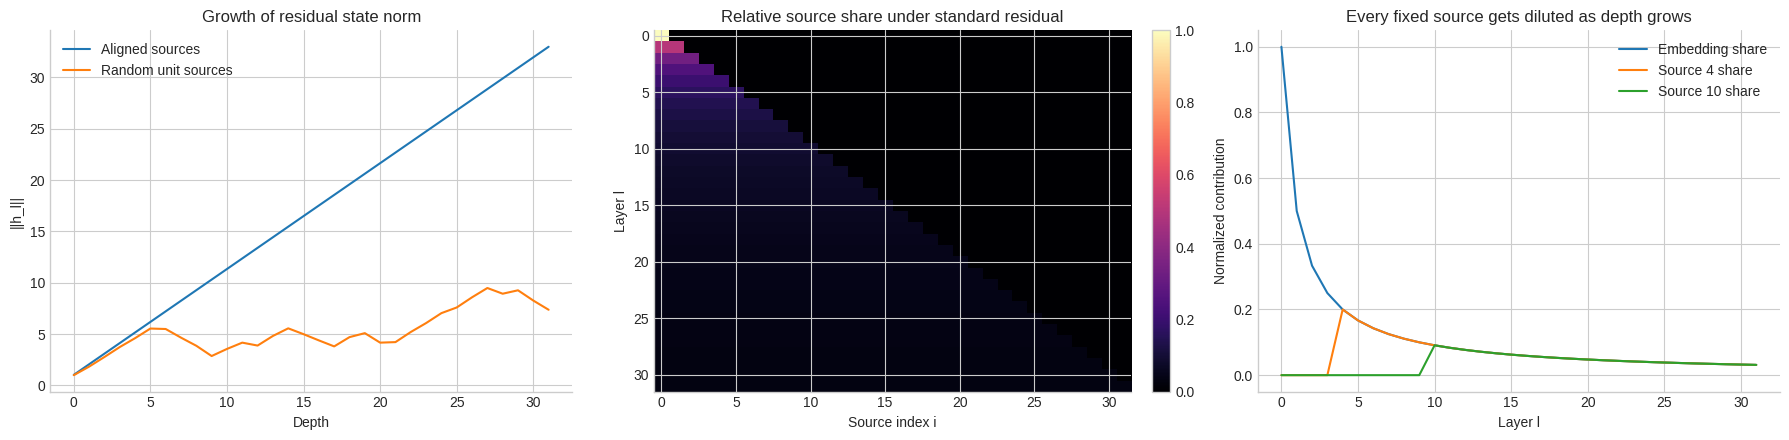

In [26]:
# 先只看“固定累加”本身，而不引入 AttnRes。
L = 32
d = 2

aligned_sources = np.tile(np.array([[1.0, 0.25]]), (L, 1))
random_sources = np.random.randn(L, d)
random_sources = random_sources / np.linalg.norm(random_sources, axis=1, keepdims=True)

aligned_hidden = np.cumsum(aligned_sources, axis=0)
random_hidden = np.cumsum(random_sources, axis=0)

# 标准残差的 mixing matrix：严格下三角全 1。
M_std = np.tril(np.ones((L, L)))
relative_share = M_std / M_std.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(np.linalg.norm(aligned_hidden, axis=1), label="Aligned sources")
axes[0].plot(np.linalg.norm(random_hidden, axis=1), label="Random unit sources")
axes[0].set_title("Growth of residual state norm")
axes[0].set_xlabel("Depth")
axes[0].set_ylabel("||h_l||")
axes[0].legend()

im = axes[1].imshow(relative_share, aspect="auto", cmap="magma", vmin=0, vmax=1)
axes[1].set_title("Relative source share under standard residual")
axes[1].set_xlabel("Source index i")
axes[1].set_ylabel("Layer l")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].plot(relative_share[:, 0], label="Embedding share")
axes[2].plot(relative_share[:, 4], label="Source 4 share")
axes[2].plot(relative_share[:, 10], label="Source 10 share")
axes[2].set_title("Every fixed source gets diluted as depth grows")
axes[2].set_xlabel("Layer l")
axes[2].set_ylabel("Normalized contribution")
axes[2].legend()

plt.tight_layout()

- ax[0]: Growth of residual state norm
    - aligned_sources (方向一致的输出), random_sources (方向随机的输出)
    - 隐藏状态的数值规模（Magnitude）会随着深度不可逆地膨胀
- axes[1]
    - `M_std = np.tril(np.ones((L, L)))`生成了一个严格的下三角全 $1$ 矩阵 。这代表第 $l$ 层以系数 $1$ 接收了前面所有的源。
    - 然而，relative_share 将其按行归一化。数学本质：虽然绝对加法系数是 $1$，但在第 $l$ 层的总输入中，任意一个历史源的“相对话语权”（Relative Share）变成了 $\frac{1}{l}$。
- axes[2]: 早期信号的“不可逆稀释” (Dilution as depth grows)
    - Embedding 最初在第 $1$ 层占据 $100\%$ 的权重，但到了第 $24$ 层，它的份额被极其平滑且无情地稀释到了 $\frac{1}{24}$（约 $4\%$）。第 $4$ 层和第 $10$ 层的特征同样面临“一旦产生，便开始衰减”的宿命。